In [82]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import nltk


tweets_df = pd.read_csv("https://raw.githubusercontent.com/KCristopher/SentimentAnalysis/main/sts_gold_tweet.csv")
tweets_df.head()

,id,polarity,tweet
0,1467933112,0,the angel is going to miss the athlete this we...
1,2323395086,0,It looks as though Shaq is getting traded to C...
2,1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH
3,1990283756,0,drinking a McDonalds coffee and not understand...
4,1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...


In [83]:
tweets_df.shape

(2034, 3)

In [84]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2034 non-null   int64 
 1   polarity  2034 non-null   int64 
 2   tweet     2034 non-null   object
dtypes: int64(2), object(1)
memory usage: 47.8+ KB


In [85]:
tweets_df['id'].nunique(), len(tweets_df)

(2034, 2034)

In [86]:
tweets_df.groupby('id')['tweet'].nunique().sort_values(ascending = False).head(10)

id
1467812416    1
2052262229    1
2053125094    1
2053014136    1
2052945734    1
2052940465    1
2052939840    1
2052859663    1
2052844839    1
2052807447    1
Name: tweet, dtype: int64

In [87]:
( tweets_df.groupby('id')['tweet'].nunique() == 1 ).all()

True

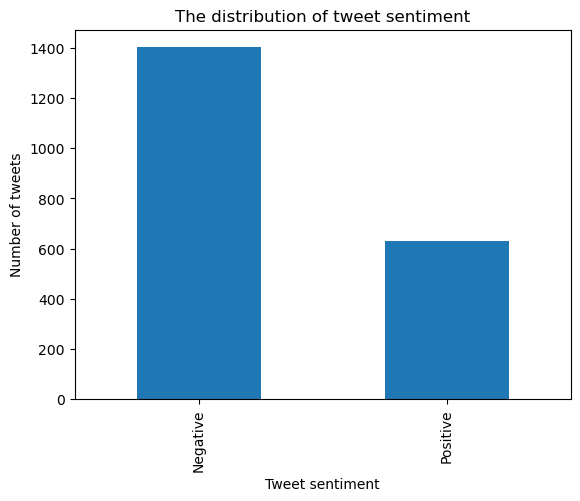

In [88]:
ax = tweets_df['polarity'].value_counts(dropna = False).plot.bar()
plt.title("The distribution of tweet sentiment")
plt.xticks(ax.get_xticks(), ['Negative', 'Positive'])
plt.ylabel('Number of tweets')
plt.xlabel('Tweet sentiment')
plt.show()

In [89]:
sample_tweets = tweets_df[['polarity', 'tweet']].sample(n = 10)

for row in sample_tweets.iterrows() :
    print('\n', row[1]['tweet'], '  >>>>>>>  ', row[1]['polarity'], '\n')


 @dougiemcfly &quot;Last show in Brazil&quot; read this is so sad!    >>>>>>>   0 


 @kennyseattle1  Hi Kenny !! Welcome to twitterville and get ready to waste tons of hours having fun on here. See u live at 5am on Q13 FOX    >>>>>>>   4 


 cloudy in london please don't rain    >>>>>>>   0 


 Just had a horrible message left on one of my YouTube videos, just when I was starting to feel better    >>>>>>>   0 


 Sad story this one  http://bit.ly/7GU8A U hav to wonder if Obama's pro-choice stance is a genuine threat to his life.   >>>>>>>   0 


 homework homework homework    >>>>>>>   0 


 Youtube and Facebook ftw!    >>>>>>>   4 


 my little pinky finger hurts so much..    >>>>>>>   0 


 I miss my iPod...life just isn't the same without it    >>>>>>>   0 


 IN DESPERATE NEED FOR IPHONE MONEY (srsly, me needs a phone that works!  ) AND ITUNES MONEY! :O   >>>>>>>   0 



In [90]:
tweets_df['tweet_length'] = tweets_df['tweet'].str.len()
tweets_df['tweet_length'].describe().round(2)

count    2034.00
mean       80.81
std        35.36
min        11.00
25%        51.00
50%        77.50
75%       111.00
max       148.00
Name: tweet_length, dtype: float64

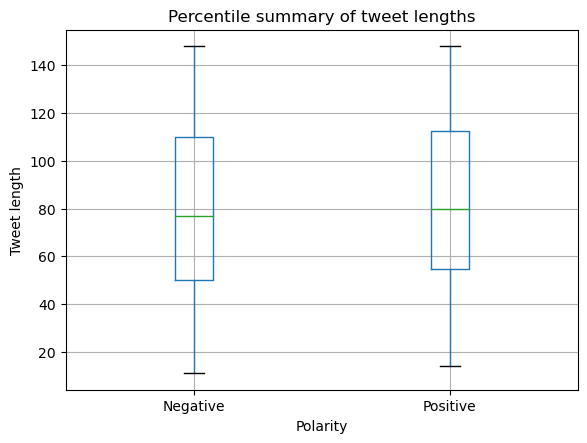

In [91]:
lengths_box = tweets_df.boxplot(column='tweet_length', by='polarity')
plt.suptitle('')
plt.title('Percentile summary of tweet lengths')
plt.xticks( lengths_box.get_xticks(), [ 'Negative', 'Positive' ] )
plt.ylabel('Tweet length')
plt.xlabel('Polarity')

plt.show()

In [92]:
tweets_df.set_index('id', inplace = True)
tweets_df.head()

,polarity,tweet,tweet_length
id,,,
1467933112,0,the angel is going to miss the athlete this we...,52
2323395086,0,It looks as though Shaq is getting traded to C...,126
1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH,46
1990283756,0,drinking a McDonalds coffee and not understand...,100
1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...,51


In [93]:
y = tweets_df['polarity']
X = tweets_df.drop('polarity', axis = 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

trainset = pd.concat( [ X_train, y_train ], axis = 1  )
testset = pd.concat( [ X_test, y_test ], axis = 1  )

In [94]:
trainset.shape, testset.shape

((1362, 3), (672, 3))

In [95]:
trainset.polarity.value_counts(normalize = True).round(2)

0    0.7
4    0.3
Name: polarity, dtype: float64

In [96]:
testset.polarity.value_counts(normalize = True).round(2)

0    0.68
4    0.32
Name: polarity, dtype: float64

In [97]:
words_dataset = ' '.join( trainset['tweet'].tolist() )
words_dataset[ : 100]

'Facebook Make me SAD  T.T Anyone using #TweetDeck?  Their latest version update v0.25.1b still does '

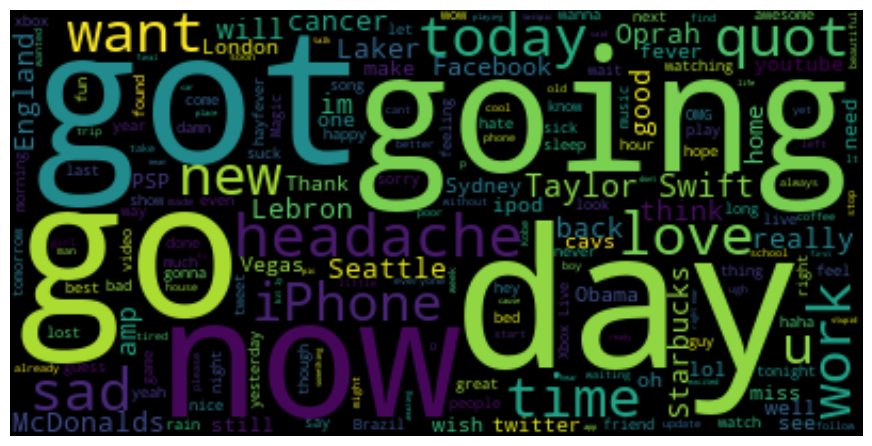

In [98]:
# Create and generate a word cloud image:
wordcloud = WordCloud().generate(words_dataset)

# Display the generated image:
plt.figure(figsize=(11,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [99]:
trainset.head(3)

,tweet,tweet_length,polarity
id,,,
2175019150,Facebook Make me SAD T.T,25,0
2174569897,Anyone using #TweetDeck? Their latest version...,119,0
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,91,4


In [100]:
raw_tokens_dataset = [ t for tweet in trainset.tweet for t in tweet.split() ]
raw_tokens_dataset[ : 10]

['Facebook',
 'Make',
 'me',
 'SAD',
 'T.T',
 'Anyone',
 'using',
 '#TweetDeck?',
 'Their',
 'latest']

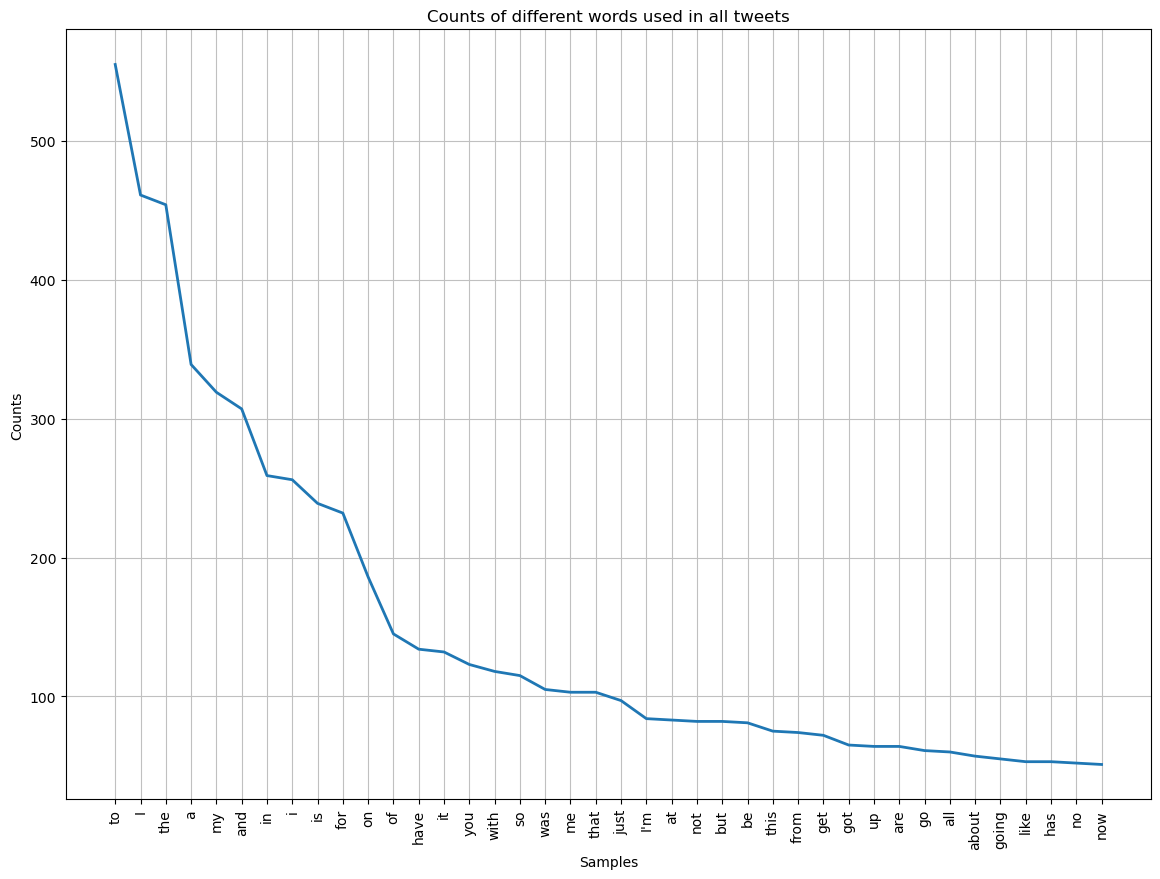

In [101]:
# Creating the word frequency distribution
freqdist = nltk.FreqDist(raw_tokens_dataset)

# Plotting the word frequency distribution
plt.figure(figsize=(14,10))
freqdist.plot(40,title='Counts of different words used in all tweets')

plt.show()

In [102]:
freqdist.most_common(40)

[('to', 555),
 ('I', 461),
 ('the', 454),
 ('a', 339),
 ('my', 319),
 ('and', 307),
 ('in', 259),
 ('i', 256),
 ('is', 239),
 ('for', 232),
 ('on', 186),
 ('of', 145),
 ('have', 134),
 ('it', 132),
 ('you', 123),
 ('with', 118),
 ('so', 115),
 ('was', 105),
 ('me', 103),
 ('that', 103),
 ('just', 97),
 ("I'm", 84),
 ('at', 83),
 ('not', 82),
 ('but', 82),
 ('be', 81),
 ('this', 75),
 ('from', 74),
 ('get', 72),
 ('got', 65),
 ('up', 64),
 ('are', 64),
 ('go', 61),
 ('all', 60),
 ('about', 57),
 ('going', 55),
 ('like', 53),
 ('has', 53),
 ('no', 52),
 ('now', 51)]

In [103]:
stop_words_keep = [ 'no', 'not', 'now', 'like', 'but', 'just' ]

In [104]:
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Predator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [105]:
stop_words = list( set(stopwords.words('english')) )
stop_words[ : 10]

['had',
 'over',
 'other',
 'doesn',
 'its',
 'about',
 'hadn',
 'couldn',
 "we'll",
 'himself']

In [106]:
custom_stop_words = [ sw for sw in stop_words if sw not in stop_words_keep ]

In [107]:
trainset_positive = trainset [ trainset['polarity'] == 4 ]
trainset_negative = trainset [ trainset['polarity'] == 0 ]
trainset_positive.polarity.value_counts()

4    415
Name: polarity, dtype: int64

In [108]:
trainset_positive.head()

,tweet,tweet_length,polarity
id,,,
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,91,4
1932994382,"Just got back from market-market, bought the 8...",83,4
2190562741,"Had a piece of fried chicken, some PSP luv and...",63,4
1687934386,Seattle is sunny atm. Need to go take advant...,110,4
1467861393,@SwitchItNow ahhh shiner Bock in Austin YES! t...,95,4


In [109]:
trainset_positive_words = [ t for string in trainset_positive['tweet'] for t in string.split() ]
trainset_positive_words[ : 3]

['@JBsFanArgentina', 'Hey', 'I']

In [110]:
trainset_negative_words = [ t for string in trainset_negative['tweet'] for t in string.split() ]

In [111]:
trainset_positive_no_stop = [ word for word in trainset_positive_words if word.lower() not in custom_stop_words ]
trainset_negative_no_stop = [ word for word in trainset_negative_words if word.lower() not in custom_stop_words ]

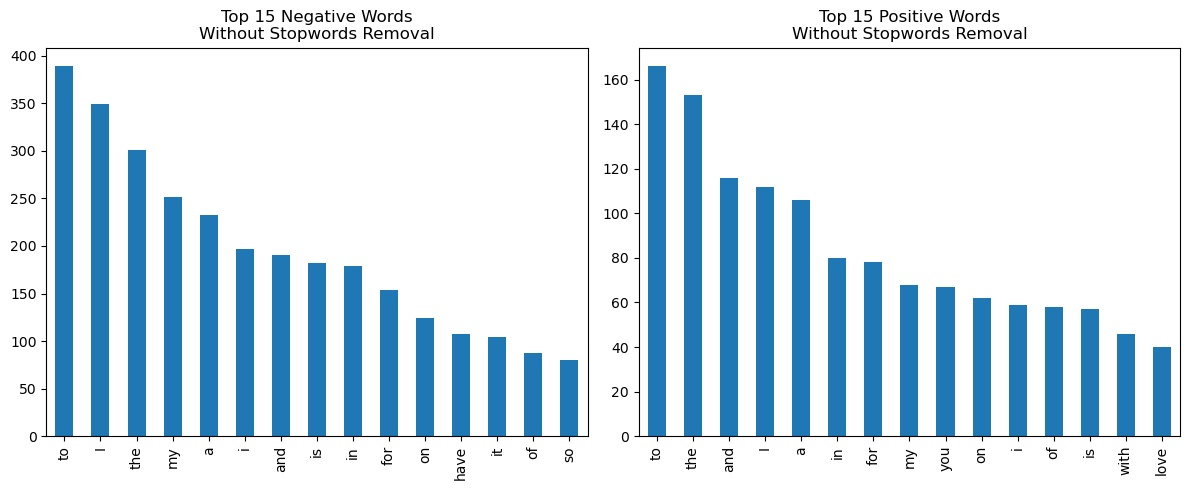

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Negative words
pd.Series(trainset_negative_words)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes[0], title="Top 15 Negative Words\nWithout Stopwords Removal")

# Positive words
pd.Series(trainset_positive_words)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes[1], title="Top 15 Positive Words\nWithout Stopwords Removal")

plt.tight_layout()
plt.show()

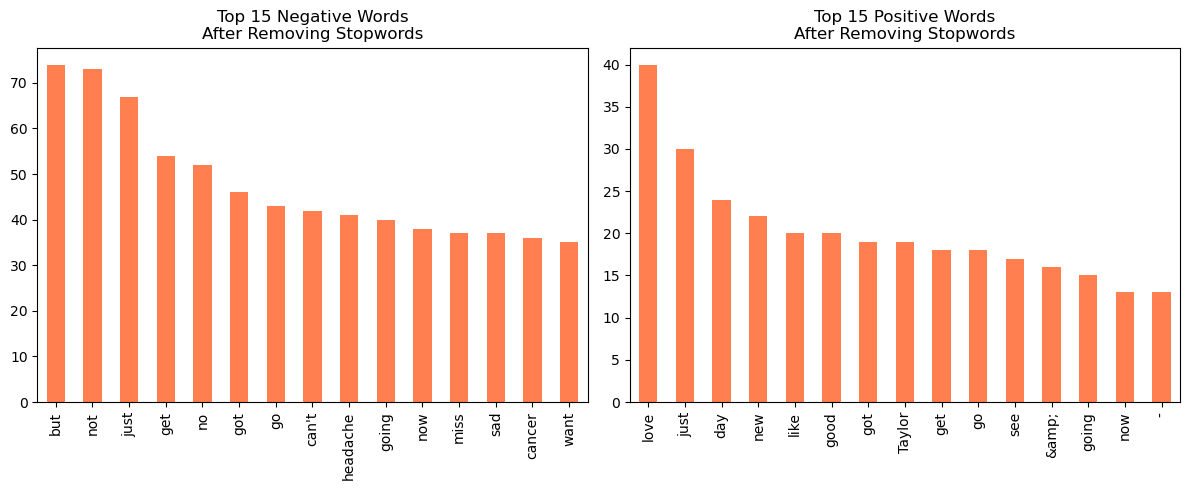

In [113]:
fig_two, axes_two = plt.subplots(1, 2, figsize=(12, 5))

# Negative words
pd.Series(trainset_negative_no_stop)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes_two[0], title="Top 15 Negative Words\nAfter Removing Stopwords", color = 'coral')

# Positive words
pd.Series(trainset_positive_no_stop)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes_two[1], title="Top 15 Positive Words\nAfter Removing Stopwords", color = 'coral')

plt.tight_layout()
plt.show()

In [118]:

pos_counts = pd.Series(trainset_positive_no_stop).value_counts()
neg_counts = pd.Series(trainset_negative_no_stop).value_counts()

# combine into one dataframe
df = pd.DataFrame({
    "pos": pos_counts,
    "neg": neg_counts
}).fillna(0)

# avoid division by zero
df["pos_ratio"] = (df["pos"] + 1) / (df["neg"] + 1)
df["neg_ratio"] = (df["neg"] + 1) / (df["pos"] + 1)

df.sort_values(by = 'pos_ratio', ascending = False).head()

,pos,neg,pos_ratio,neg_ratio
Thank,6.0,0.0,7.000000,0.142857
LOL,6.0,0.0,7.000000,0.142857
love,40.0,5.0,6.833333,0.146341
n,5.0,0.0,6.000000,0.166667
"awesome,",4.0,0.0,5.000000,0.200000


In [121]:
df.sort_values(by = 'neg_ratio', ascending = False).head()

,pos,neg,pos_ratio,neg_ratio
no,0.0,52.0,0.018868,53.0
headache,0.0,41.0,0.023810,42.0
sad,0.0,37.0,0.026316,38.0
fever,0.0,25.0,0.038462,26.0
bad,0.0,24.0,0.040000,25.0


In [120]:
df[[ 'pos_ratio', 'neg_ratio' ]].describe().round(2)

,pos_ratio,neg_ratio
count,5946.00,5946.00
mean,0.99,1.75
std,0.79,1.69
min,0.02,0.14
25%,0.50,0.50
50%,0.50,2.00
75%,2.00,2.00
max,7.00,53.00


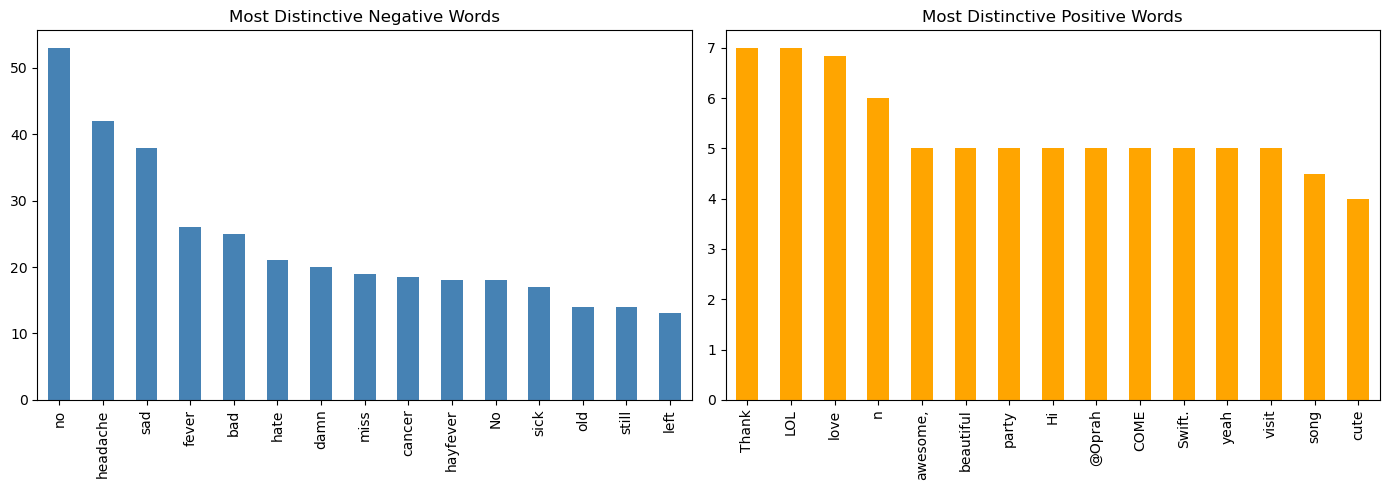

In [119]:
# top distinctive words
top_pos = df["pos_ratio"].sort_values(ascending=False).head(15)
top_neg = df["neg_ratio"].sort_values(ascending=False).head(15)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14,5))

top_neg.plot.bar(ax=axes[0], color="steelblue",
                 title="Most Distinctive Negative Words")

top_pos.plot.bar(ax=axes[1], color="orange",
                 title="Most Distinctive Positive Words")

plt.tight_layout()
plt.show()